In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install numpy==1.24.3


   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
   -- ------------------------------------- 1.0/14.8 MB 474.9 kB/s eta 0:00:30
   --- ------------------------------------ 1.3/14.8 MB 599.2 kB/s eta 0:00:23
   --- ------------------------------------ 1.3/14.8 MB 599.2 kB/s eta 0:00:23
   ---- ----------------------------------- 1.8/14.8 MB 694.4 k

  You can safely remove it manually.
  You can safely remove it manually.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os
import glob as gb
import glob
import cv2
import tensorflow as tf

In [3]:
# from tensorflow.keras.applications.mobilenet_v2 import  preprocess_input

In [4]:
directory = 'D:\Project\Internship'
train='archive/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

In [5]:
size=224

In [27]:
train_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=90,
    width_shift_range=0.0,
    height_shift_range=0.0,
    shear_range=0.0,
    zoom_range=0.0,
    horizontal_flip=False,
    vertical_flip=False,
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(train,
                      batch_size=32,
                      target_size=(size,size),
                      subset="training",
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=True)

Found 126546 images belonging to 38 classes.


In [28]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

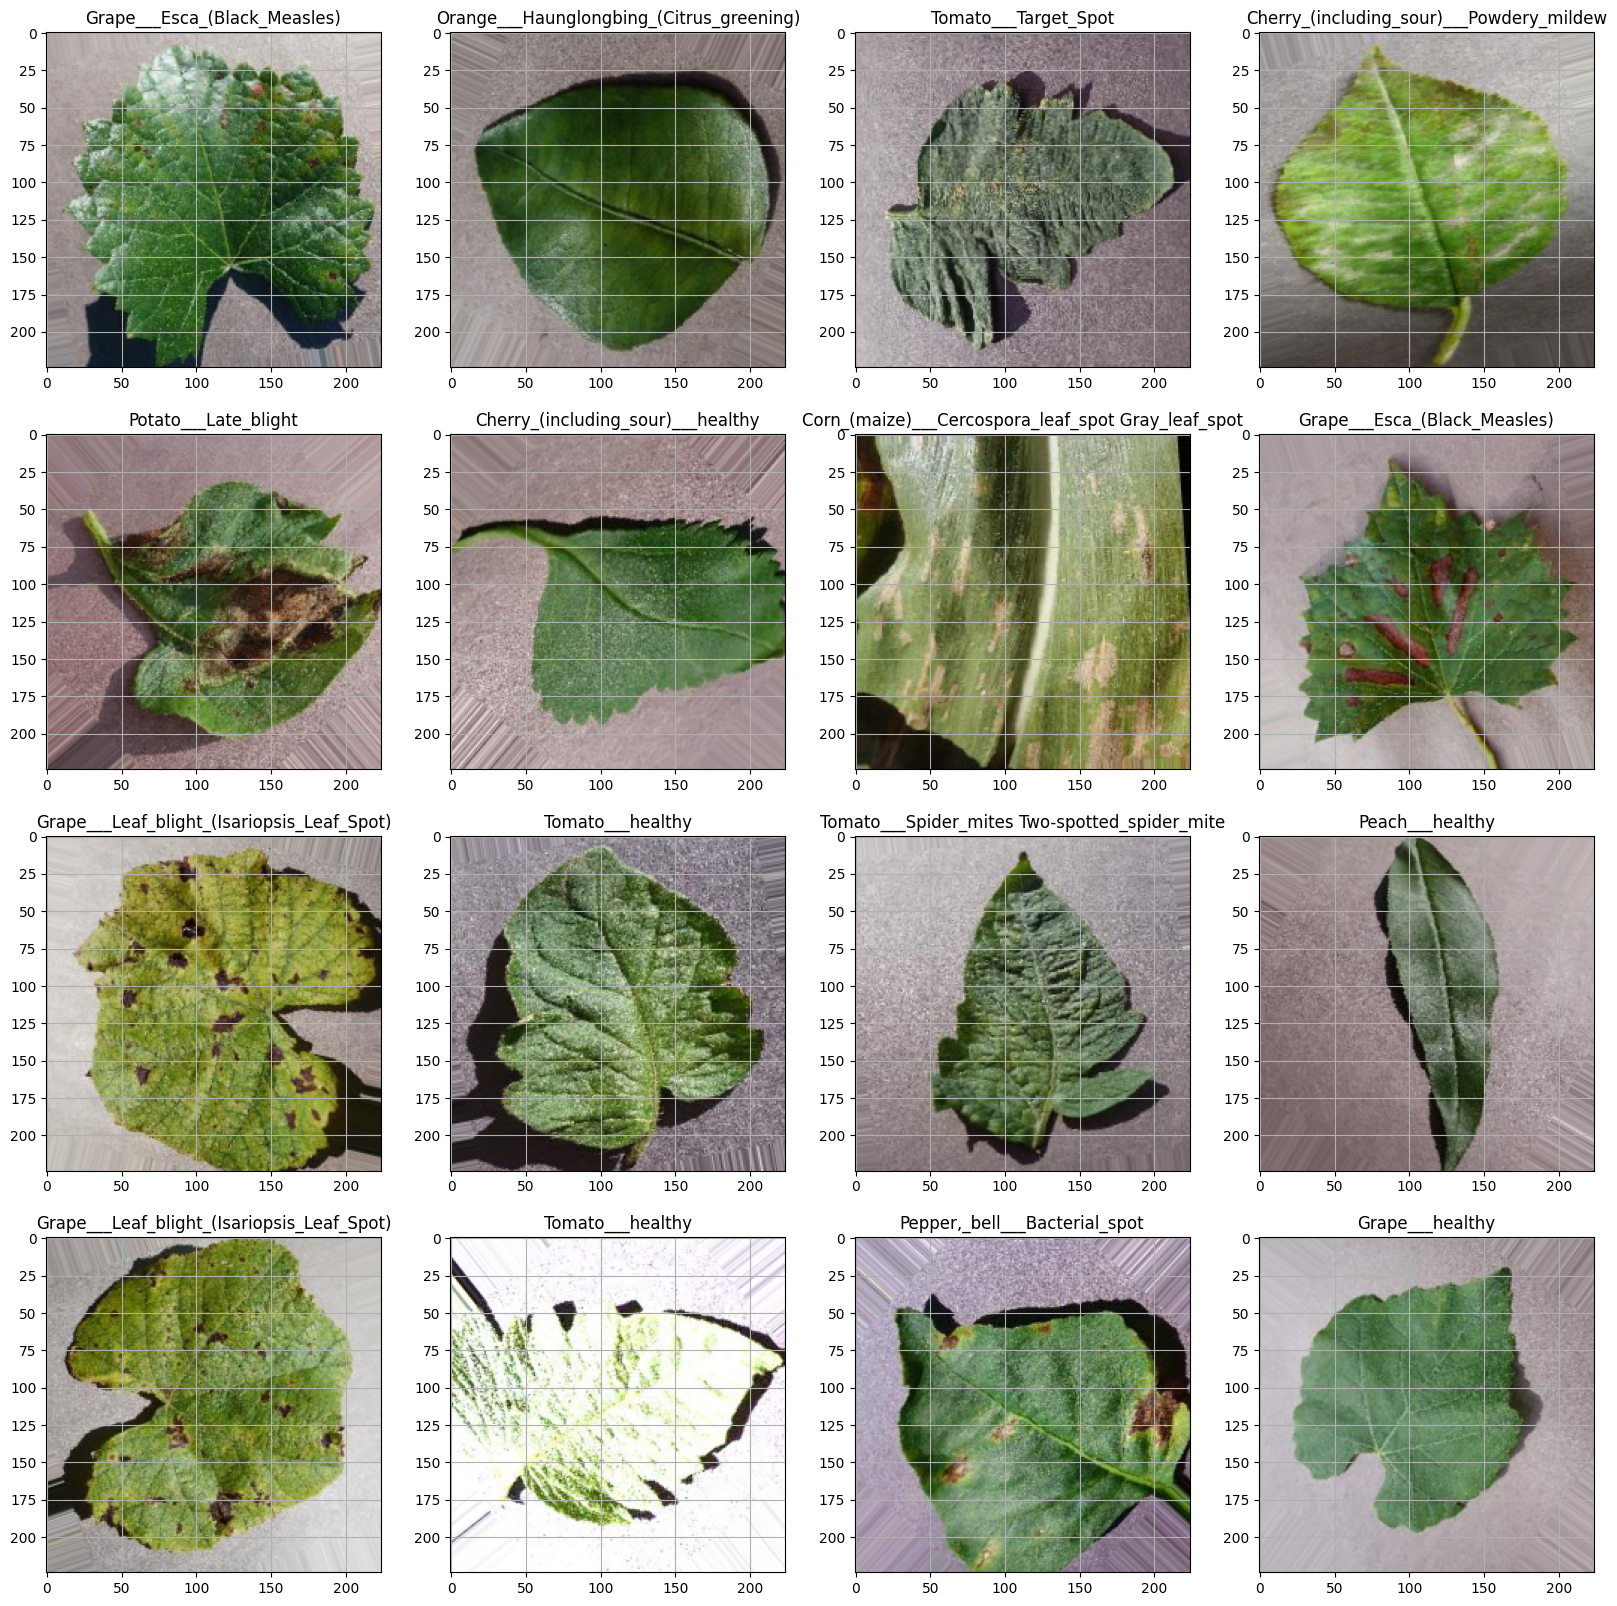

In [29]:
#let's display some images from training set

classes=list(train_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in train_generator:
    # create a grid of 3x3 images
    for i in range(0,16):
        plt.subplot(4,4,i+1)
        plt.imshow(X_batch[i])
        plt.title(classes[np.where(y_batch[i]==1)[0][0]])   # when y is categorical
        # plt.title(classes[int(y_batch[i])])   # when y is binary or sparse
        plt.grid(None)
    # show the plot
    plt.show()
    break


In [30]:
valid='archive/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'


In [31]:
valid_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(valid,
                      batch_size=32,
                      target_size=(224,224),
                      subset='validation',
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=False)

Found 3503 images belonging to 38 classes.


In [32]:
test='archive/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
).flow_from_directory(test,
                      batch_size=32,
                      target_size=(224,224),
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=False)

Found 35144 images belonging to 38 classes.


In [33]:
test_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [34]:
from tensorflow import keras
model = keras.models.Sequential()  # To build NN

model.add(keras.layers.Conv2D(filters=32, kernel_size=7, strides=1,
                padding="same", activation="relu", name="Conv1", input_shape= (224,224,3)))

model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))

model.add(keras.layers.Conv2D(filters=64, kernel_size=5, strides=1,
                              padding="same", activation="relu", name="Conv2"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))

model.add(keras.layers.Conv2D(filters=128, kernel_size=3, strides=1,
                              padding="same", activation="relu", name="Conv3"))

model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1,
                              padding="same", activation="relu", name="Conv4"))

model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

model.add(keras.layers.Flatten(name="Flatten1"))   #flatten layer - to convert into 1d vector

model.add(keras.layers.Dense(128, activation="relu", name="Dense1"))  #hidden layer
tf.keras.layers.Dropout(0.5)

model.add(keras.layers.Dense(64, activation="relu", name="Dense2"))  #hidden layer
tf.keras.layers.Dropout(0.5)

model.add(keras.layers.Dense(38, activation="softmax", name="Output"))  #output layer

# The model’s summary() method displays all the model’s layers
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1 (Conv2D)              (None, 224, 224, 32)      4736      
                                                                 
 Pool1 (MaxPooling2D)        (None, 112, 112, 32)      0         
                                                                 
 Conv2 (Conv2D)              (None, 112, 112, 64)      51264     
                                                                 
 Pool2 (MaxPooling2D)        (None, 56, 56, 64)        0         
                                                                 
 Conv3 (Conv2D)              (None, 56, 56, 128)       73856     
                                                                 
 Conv4 (Conv2D)              (None, 56, 56, 256)       295168    
                                                                 
 Pool3 (MaxPooling2D)        (None, 28, 28, 256)      

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

model_ReduceLROnPlateau = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=0.000001)

callbacks=[early_stopping,model_checkpoint,model_ReduceLROnPlateau]

In [1]:
pip install scipy


   ---------------------------------------- 0.0/44.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.8 MB 441.3 kB/s eta 0:01:41
   ---------------------------------------- 0.5/44.8 MB 441.3 kB/s eta 0:01:41
    --------------------------------------- 0.8/44.8 MB 516.0 kB/s eta 0:01:26
    --------------------------------------- 0.8/44.8 MB 516.0 kB/s eta 0:01:26
    --------------------------------------- 1.0/44.8 MB 508.4 kB/s eta 0:01:27
    --------------------------------------- 1.0/44.8 MB 508.4 kB/s eta 0:01:27
    --------------------------------------- 1.0/44.8 MB 508.4 kB/s eta 0:01:27
    --------------------------------------- 1.0/44.8 MB 508.4 kB/s eta 0:01:27
   - -------------

In [36]:
model.compile(loss='categorical_crossentropy', optimizer= 'Adam', metrics=["accuracy"])

In [17]:
from tensorflow.keras.metrics import Precision

In [37]:
history = model.fit(train_generator,
                    epochs          = 5,
                    validation_data = valid_generator,
                    callbacks = callbacks
                    )

Epoch 1/5
3955/3955 [==============================] - 3911s 985ms/step - loss: 1.2825 - accuracy: 0.6095 - val_loss: 0.5472 - val_accuracy: 0.8267 - lr: 0.0010
Epoch 2/5
3955/3955 [==============================] - 2556s 646ms/step - loss: 0.4193 - accuracy: 0.8628 - val_loss: 0.4342 - val_accuracy: 0.8576 - lr: 0.0010
Epoch 3/5
3955/3955 [==============================] - 1361s 344ms/step - loss: 0.2858 - accuracy: 0.9045 - val_loss: 0.3617 - val_accuracy: 0.8875 - lr: 0.0010
Epoch 4/5
3955/3955 [==============================] - 1033s 261ms/step - loss: 0.2227 - accuracy: 0.9260 - val_loss: 0.3361 - val_accuracy: 0.8975 - lr: 0.0010
Epoch 5/5
3955/3955 [==============================] - 990s 250ms/step - loss: 0.1927 - accuracy: 0.9357 - val_loss: 0.2353 - val_accuracy: 0.9283 - lr: 0.0010


In [40]:
import seaborn as sns
sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# precision = history.history['precision']
# val_precision = history.history['val_precision']

# recall =history.history['recall']
# val_recall =history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

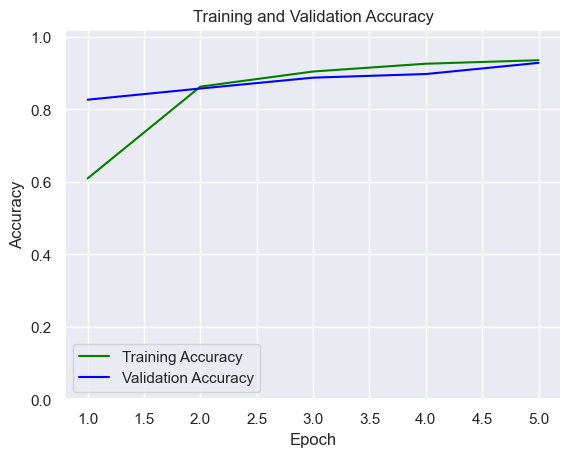

In [41]:
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim(0,1.02)
plt.show()

In [42]:
model_evaluate = model.evaluate(test_generator)
print("Loss     : ",model_evaluate[0])
print("Accuracy : ",model_evaluate[1])
# print("Precision  : ",model_evaluate[2])
# print("Recall : ",model_evaluate[3])

1099/1099 [==============================] - 406s 369ms/step - loss: 0.2223 - accuracy: 0.9307
Loss     :  0.22228993475437164
Accuracy :  0.9306851625442505


In [43]:
model.save('CNN_plantdiseases_model.keras')